# HumanForYou - Modelisation

L'objectif c'est de predire si un employe va partir (Attrition = 1). C'est un probleme de classification binaire, pas de regression (on ne predit pas une valeur continue) ni de clustering (on a des etiquettes connues).

On compare plusieurs algorithmes, mais en faisant attention a ce que les comparaisons aient du sens. On procede en deux temps :

**Partie 1** : on compare 4 familles d'algorithmes vraiment differentes - regression logistique, arbre de decision, k-NN, SVM. Ces 4 la representent des approches fondamentalement differentes, c'est pertinent de les mettre face a face.

**Partie 2** : on montre la progression arbre de decision vers Random Forest. Le RF n'est pas un concurrent du DT, c'est son evolution directe (un ensemble de DTs). On le traite separement pour que ce soit logique.

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection  import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model     import LogisticRegression
from sklearn.tree             import DecisionTreeClassifier, plot_tree
from sklearn.neighbors        import KNeighborsClassifier
from sklearn.svm              import SVC
from sklearn.ensemble         import RandomForestClassifier
from sklearn.metrics          import (classification_report, roc_auc_score,
                                      f1_score, ConfusionMatrixDisplay, roc_curve)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

PROC = "../data/processed/" 

## 1. Chargement des donnees

In [2]:
df = pd.read_csv(PROC + "dataset_final.csv")

X = df.drop(columns=["Attrition", "EmployeeID"])
y = df["Attrition"]

print(f"X : {X.shape}")
print(f"y : {y.value_counts().to_dict()}")

X : (4410, 43)
y : {0: 3699, 1: 711}


## 2. Split train / test

80% pour l'entrainement, 20% pour le test. Le `stratify=y` garantit qu'on garde la meme proportion de partants dans les deux parties - indispensable vu le desequilibre.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train : {X_train.shape[0]} lignes ({y_train.mean()*100:.1f}% de departs)")
print(f"Test  : {X_test.shape[0]} lignes ({y_test.mean()*100:.1f}% de departs)")

Train : 3528 lignes (16.1% de departs)
Test  : 882 lignes (16.1% de departs)


## 3. Fonction d'evaluation commune

On definit une fonction unique pour evaluer tous les modeles de facon identique. Ca garantit une comparaison juste.

In [4]:
def evaluer(nom, modele, X_train, X_test, y_train, y_test):
    modele.fit(X_train, y_train)
    y_pred  = modele.predict(X_test)
    y_proba = modele.predict_proba(X_test)[:, 1] if hasattr(modele, "predict_proba") \
              else modele.decision_function(X_test)

    auc = roc_auc_score(y_test, y_proba)
    f1  = f1_score(y_test, y_pred)

    print(f"\n{'='*50}")
    print(f"  {nom}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, target_names=["Reste", "Part"]))
    print(f"AUC-ROC : {auc:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=["Reste", "Part"], cmap="Blues", ax=axes[0]
    )
    axes[0].set_title(f"Matrice de confusion - {nom}")
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    axes[1].plot(fpr, tpr, color="steelblue", label=f"AUC = {auc:.3f}")
    axes[1].plot([0,1],[0,1],"k--", label="Aleatoire")
    axes[1].set_xlabel("Taux faux positifs")
    axes[1].set_ylabel("Rappel")
    axes[1].set_title(f"Courbe ROC - {nom}")
    axes[1].legend()
    plt.tight_layout()
    fname = nom.lower().replace(" ", "_").replace("e", "e")
    plt.savefig(f"../outputs/{fname}_eval.png", bbox_inches="tight")
    plt.show()

    return {"nom": nom, "f1": f1, "auc": auc, "y_proba": y_proba, "modele": modele}

resultats_base = []

## Partie 1 - Comparaison de 4 familles d'algorithmes

Ces 4 modeles ont des logiques fondamentalement differentes :
- **Regression logistique** : modele lineaire, cherche une frontiere droite entre les classes
- **Arbre de decision** : regles if/else apprises automatiquement, tres interpretable
- **k-NN** : prediction par similarite avec les voisins les plus proches dans les donnees
- **SVM** : cherche la frontiere qui maximise la marge entre les deux classes

### Modele 1 - Regression Logistique (notre baseline)

On part du plus simple. Si les autres modeles ne font pas mieux, autant rester avec le plus interpretable. `class_weight='balanced'` permet de compenser le desequilibre 84/16 en donnant plus de poids aux departs.


  Regression Logistique
              precision    recall  f1-score   support

       Reste       0.95      0.77      0.85       740
        Part       0.39      0.77      0.52       142

    accuracy                           0.77       882
   macro avg       0.67      0.77      0.68       882
weighted avg       0.86      0.77      0.80       882

AUC-ROC : 0.8252


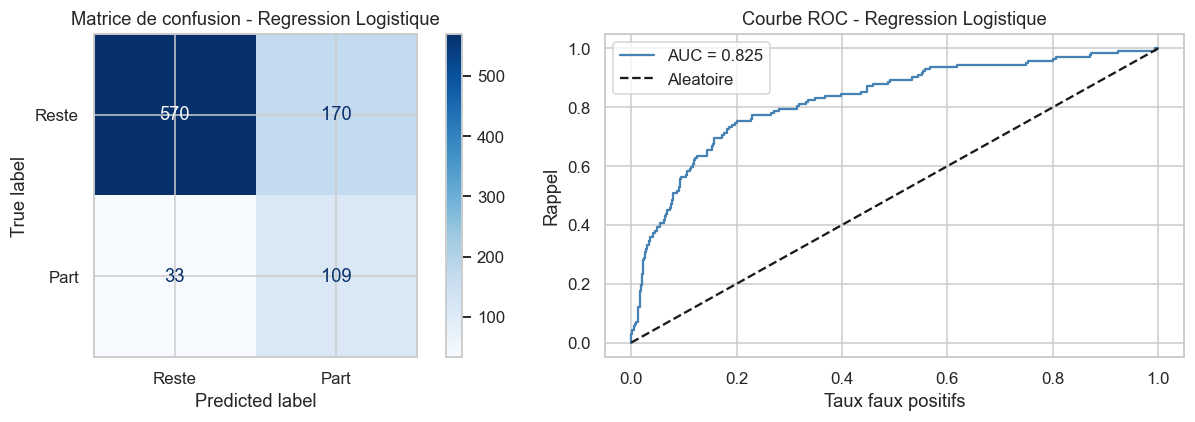

In [5]:
lr = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
resultats_base.append(evaluer("Regression Logistique", lr, X_train, X_test, y_train, y_test))

### Modele 2 - Arbre de Decision

Serie de regles if/else que le modele apprend tout seul a partir des donnees. Gros avantage : on peut visualiser et expliquer les decisions, utile si on doit justifier une prediction a la direction RH.

On limite `max_depth=5` pour eviter le surapprentissage - un arbre trop profond memorise les donnees d'entrainement mais ne generalise pas.


  Arbre de Decision
              precision    recall  f1-score   support

       Reste       0.93      0.79      0.85       740
        Part       0.38      0.69      0.49       142

    accuracy                           0.77       882
   macro avg       0.66      0.74      0.67       882
weighted avg       0.84      0.77      0.79       882

AUC-ROC : 0.7836


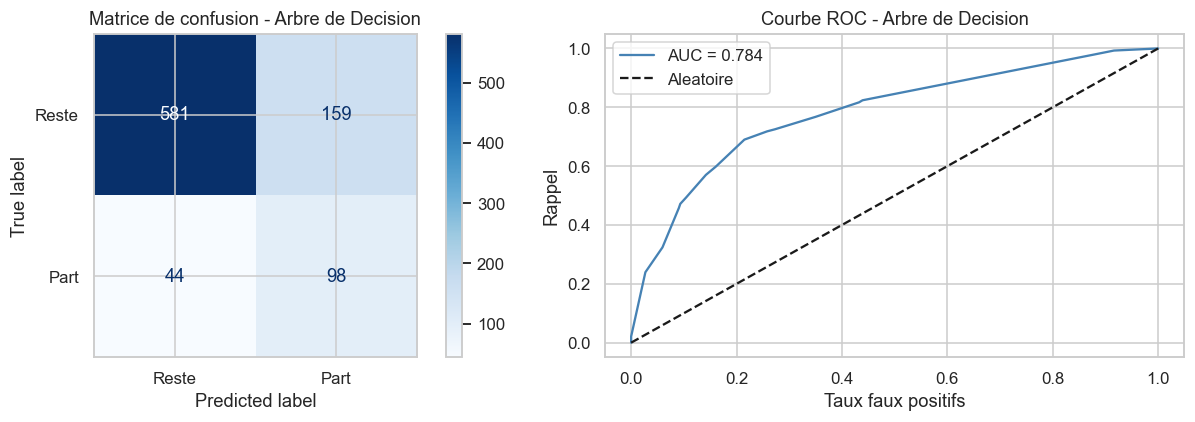

In [6]:
dt = DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=42)
resultats_base.append(evaluer("Arbre de Decision", dt, X_train, X_test, y_train, y_test))

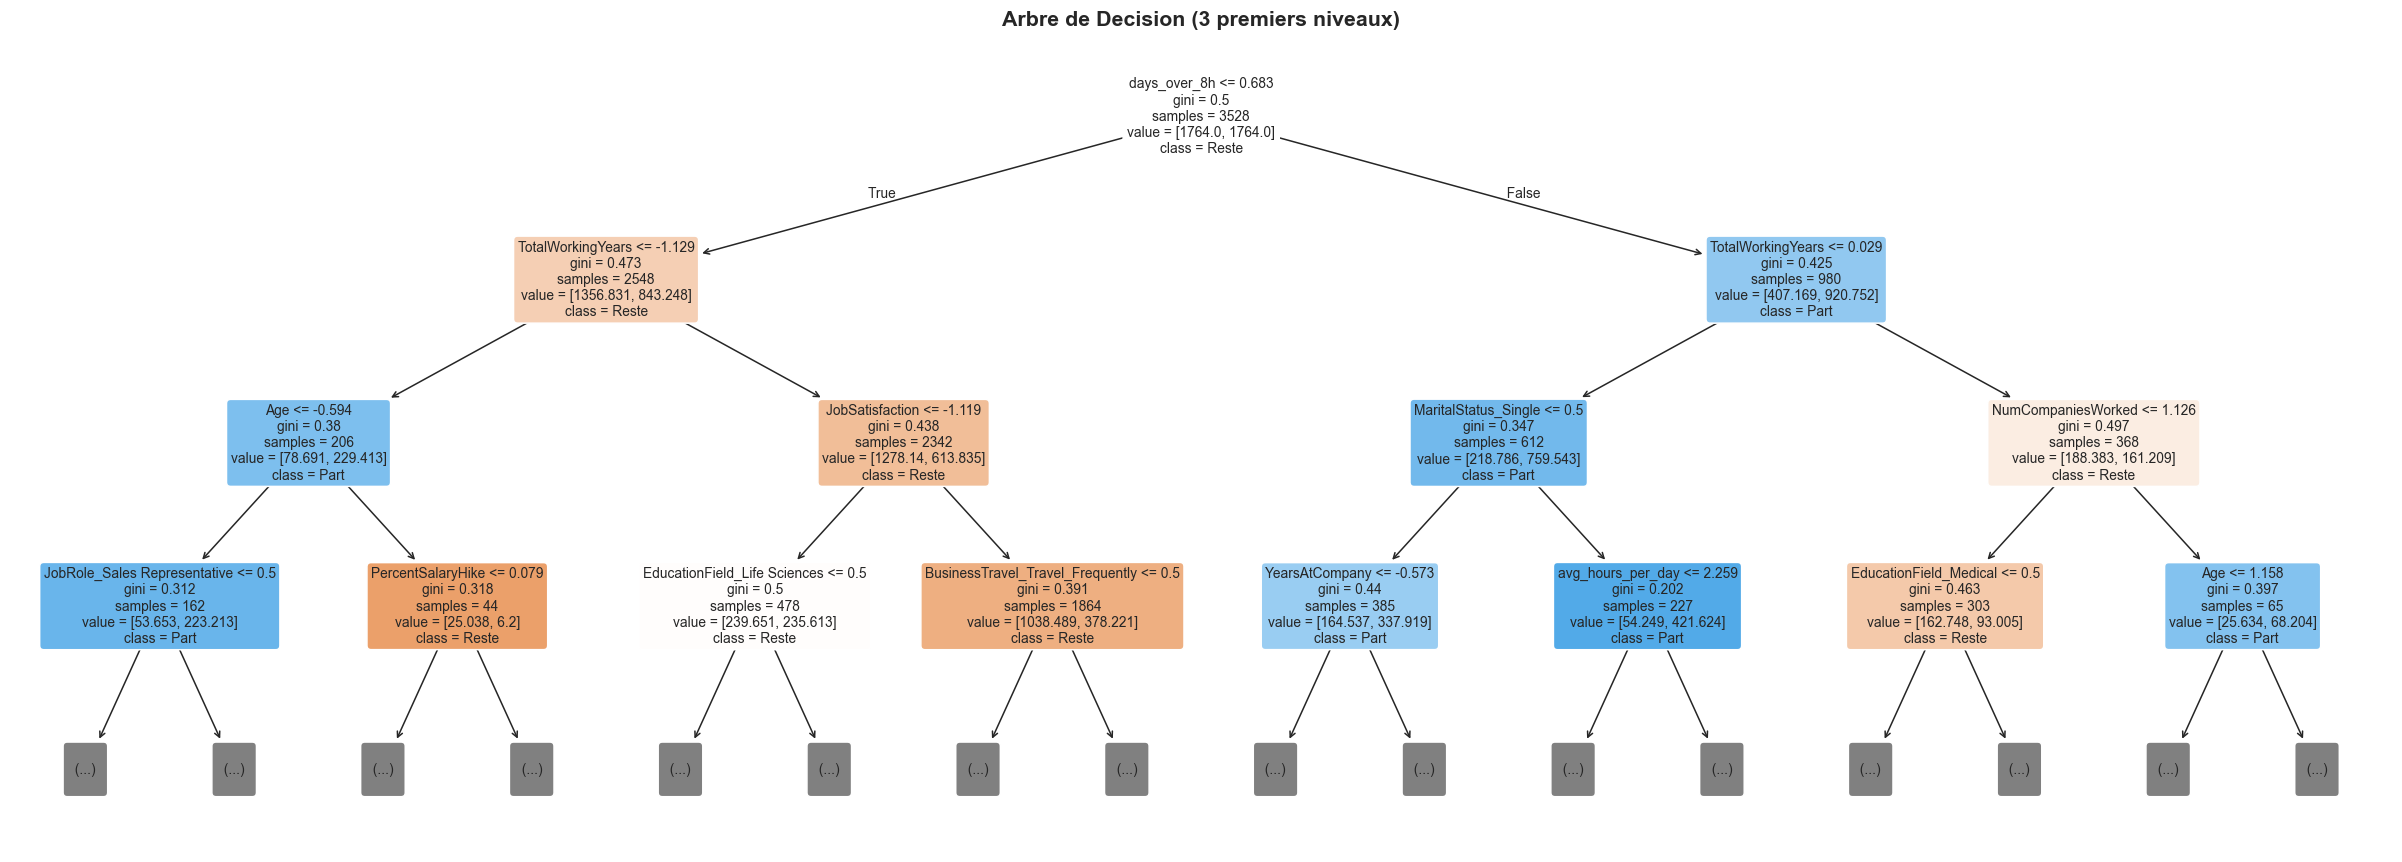

In [7]:
fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(dt, max_depth=3, feature_names=X.columns, class_names=["Reste","Part"],
          filled=True, rounded=True, ax=ax, fontsize=9)
plt.title("Arbre de Decision (3 premiers niveaux)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/arbre_decision_visu.png", bbox_inches="tight")
plt.show()

### Modele 3 - k-NN

Pour chaque employe a predire, on cherche les 11 employes les plus similaires dans les donnees d'entrainement. Si la majorite d'entre eux est partie, on predit un depart.

`k=11` (impair pour eviter les ex-aequo), `weights='distance'` : les voisins proches comptent plus que les eloignes. La normalisation faite en amont est indispensable ici, sans ca le salaire dominerait completement les calculs de distance.


  k-NN
              precision    recall  f1-score   support

       Reste       0.89      1.00      0.94       740
        Part       0.95      0.38      0.54       142

    accuracy                           0.90       882
   macro avg       0.92      0.69      0.74       882
weighted avg       0.90      0.90      0.88       882

AUC-ROC : 0.9476


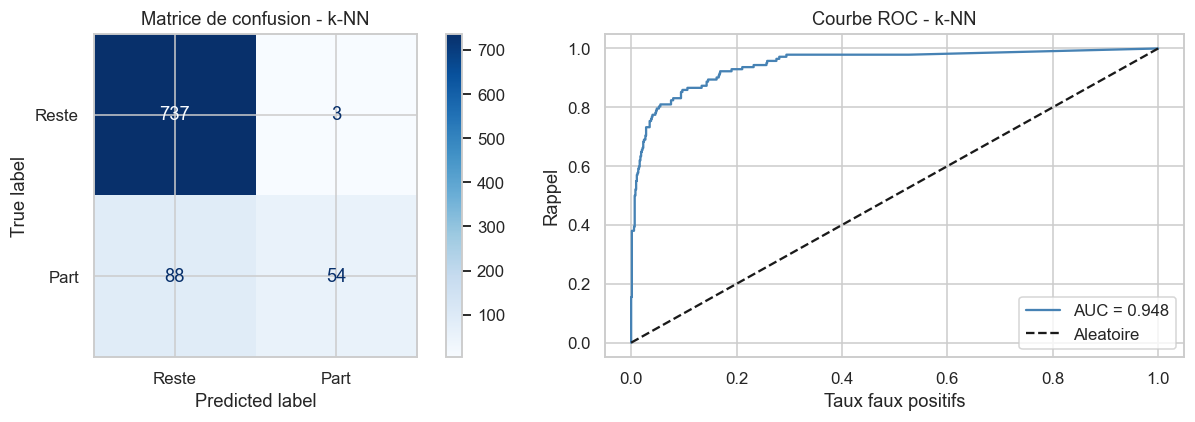

In [8]:
knn = KNeighborsClassifier(n_neighbors=11, weights="distance")
resultats_base.append(evaluer("k-NN", knn, X_train, X_test, y_train, y_test))

### Modele 4 - SVM

Le SVM trouve la frontiere qui separe les deux classes en maximisant la marge entre elles. `kernel='rbf'` pour capturer des relations non lineaires. `probability=True` pour pouvoir calculer l'AUC.


  SVM
              precision    recall  f1-score   support

       Reste       0.97      0.92      0.95       740
        Part       0.69      0.87      0.77       142

    accuracy                           0.92       882
   macro avg       0.83      0.90      0.86       882
weighted avg       0.93      0.92      0.92       882

AUC-ROC : 0.9616


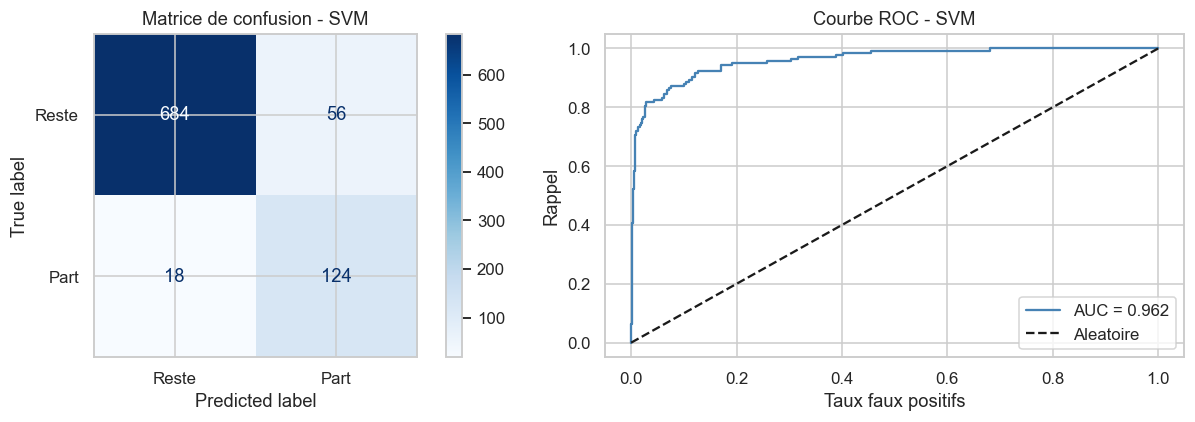

In [9]:
svm = SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=42)
resultats_base.append(evaluer("SVM", svm, X_train, X_test, y_train, y_test))

### Comparaison des 4 modeles

LR, DT, k-NN et SVM representent 4 approches fondamentalement differentes. La comparaison a du sens.

In [10]:
tableau_base = pd.DataFrame([{
    "Modele"    : r["nom"],
    "F1-score"  : round(r["f1"], 4),
    "AUC-ROC"   : round(r["auc"], 4),
} for r in resultats_base]).set_index("Modele")
print(tableau_base.to_string())

                       F1-score  AUC-ROC
Modele                                  
Regression Logistique    0.5178   0.8252
Arbre de Decision        0.4912   0.7836
k-NN                     0.5427   0.9476
SVM                      0.7702   0.9616


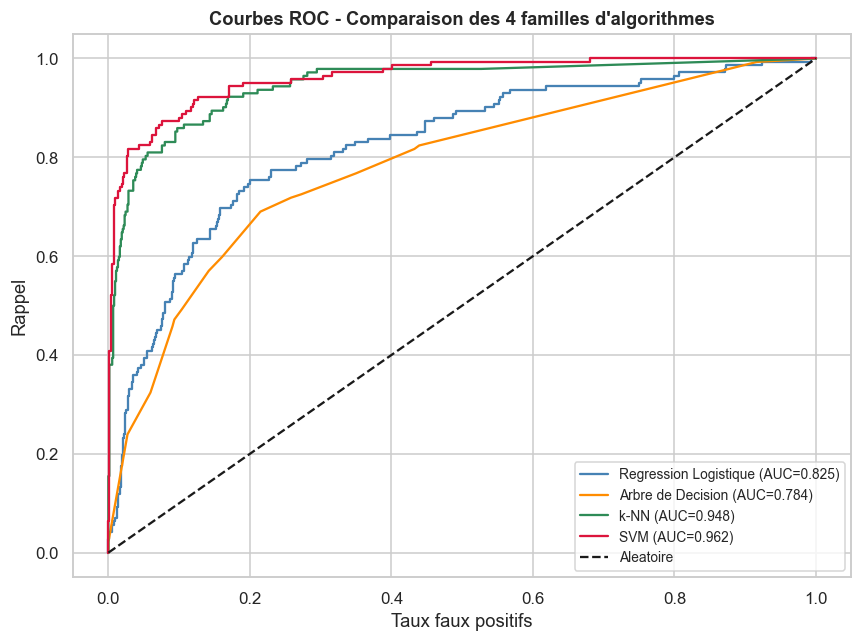

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = ["steelblue", "darkorange", "seagreen", "crimson"]

for r, color in zip(resultats_base, colors):
    fpr, tpr, _ = roc_curve(y_test, r["y_proba"])
    ax.plot(fpr, tpr, label=f"{r['nom']} (AUC={r['auc']:.3f})", color=color)

ax.plot([0,1],[0,1],"k--", label="Aleatoire")
ax.set_xlabel("Taux faux positifs")
ax.set_ylabel("Rappel")
ax.set_title("Courbes ROC - Comparaison des 4 familles d'algorithmes", fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../outputs/roc_4_modeles_base.png", bbox_inches="tight")
plt.show()

## Partie 2 - Progression : Arbre de Decision vers Random Forest

Le RF n'est pas un concurrent du DT, c'est sa version amelioree. L'arbre seul a un probleme connu : il est instable et sur-apprend. La solution, c'est d'en construire 100, chacun entraine sur un sous-ensemble aleatoire des donnees, et de faire voter tout le monde (bagging).

On compare les deux pour mesurer concretement ce que ca apporte.

In [12]:
rf = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_pred_rf = rf.predict(X_test)
y_proba_dt = dt.predict_proba(X_test)[:, 1]
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("=== DT vs RF : la progression ===")
print(f"{'Arbre de Decision (DT)':<30} F1 = {f1_score(y_test, y_pred_dt):.4f} | AUC = {roc_auc_score(y_test, y_proba_dt):.4f}")
print(f"{'Random Forest (100 arbres)':<30} F1 = {f1_score(y_test, y_pred_rf):.4f} | AUC = {roc_auc_score(y_test, y_proba_rf):.4f}")

=== DT vs RF : la progression ===
Arbre de Decision (DT)         F1 = 0.4912 | AUC = 0.7836
Random Forest (100 arbres)     F1 = 0.9283 | AUC = 0.9952


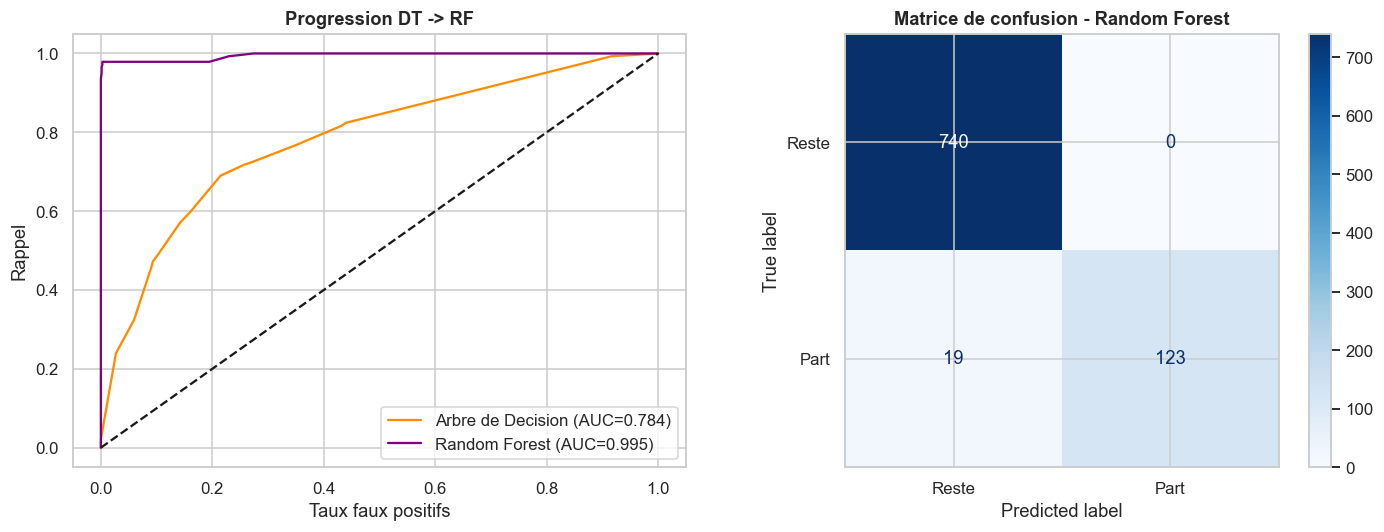

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for label, y_proba, color in [
    ("Arbre de Decision", y_proba_dt, "darkorange"),
    ("Random Forest",     y_proba_rf, "purple")
]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    axes[0].plot(fpr, tpr, label=f"{label} (AUC={auc:.3f})", color=color)
axes[0].plot([0,1],[0,1],"k--")
axes[0].set_xlabel("Taux faux positifs")
axes[0].set_ylabel("Rappel")
axes[0].set_title("Progression DT -> RF", fontweight="bold")
axes[0].legend()

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf, display_labels=["Reste","Part"], cmap="Blues", ax=axes[1]
)
axes[1].set_title("Matrice de confusion - Random Forest", fontweight="bold")

plt.tight_layout()
plt.savefig("../outputs/dt_vs_rf_progression.png", bbox_inches="tight")
plt.show()

## Partie 3 - Validation croisee sur tous les modeles

Le split train/test depend du hasard de la separation initiale. Pour une evaluation plus solide, on fait une validation croisee a 5 folds : les donnees sont decoupees en 5 parties, le modele est entraine et evalue 5 fois en changeant a chaque fois quelle partie sert de test. On inclut tous les modeles pour avoir une vue globale.

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modeles_cv = {
    "Regression Logistique": LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42),
    "Arbre de Decision"    : DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=42),
    "k-NN"                 : KNeighborsClassifier(n_neighbors=11, weights="distance"),
    "SVM"                  : SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=42),
    "Random Forest"        : RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42, n_jobs=-1),
}

cv_scores = {}
print(f"  {'Modele':<25} {'F1 moyen':>10} {'Std':>8}")
print("  " + "-"*45)
for nom, modele in modeles_cv.items():
    scores = cross_val_score(modele, X_train, y_train, cv=cv, scoring="f1")
    cv_scores[nom] = scores
    print(f"  {nom:<25} {scores.mean():>10.4f} {scores.std():>8.4f}")

  Modele                      F1 moyen      Std
  ---------------------------------------------


  Regression Logistique         0.4900   0.0135


  Arbre de Decision             0.4912   0.0207
  k-NN                          0.4267   0.0329


  SVM                           0.7363   0.0210


  Random Forest                 0.8435   0.0086


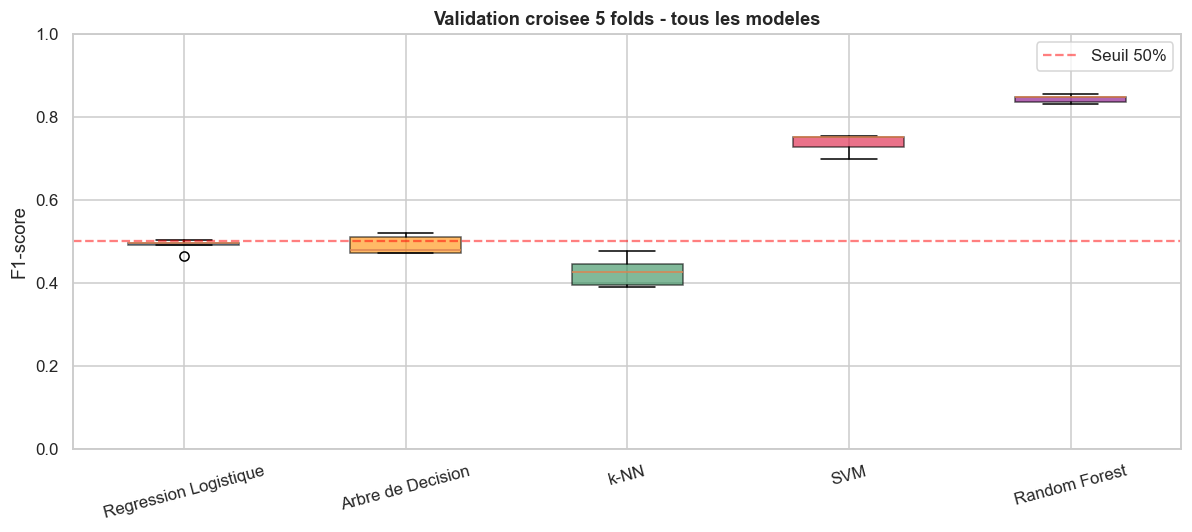

In [15]:
fig, ax = plt.subplots(figsize=(11, 5))
noms = list(cv_scores.keys())
colors_box = ["steelblue", "darkorange", "seagreen", "crimson", "purple"]
bp = ax.boxplot([cv_scores[n] for n in noms], labels=noms, patch_artist=True)
for patch, color in zip(bp["boxes"], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel("F1-score")
ax.set_title("Validation croisee 5 folds - tous les modeles", fontweight="bold")
ax.set_ylim(0, 1)
ax.axhline(0.5, color="red", linestyle="--", alpha=0.5, label="Seuil 50%")
ax.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("../outputs/crossval_comparison.png", bbox_inches="tight")
plt.show()

## Importance des variables (Random Forest)

Un des avantages du RF c'est qu'il calcule nativement l'importance de chaque variable. On en profite pour voir ce qui compte le plus dans les predictions.

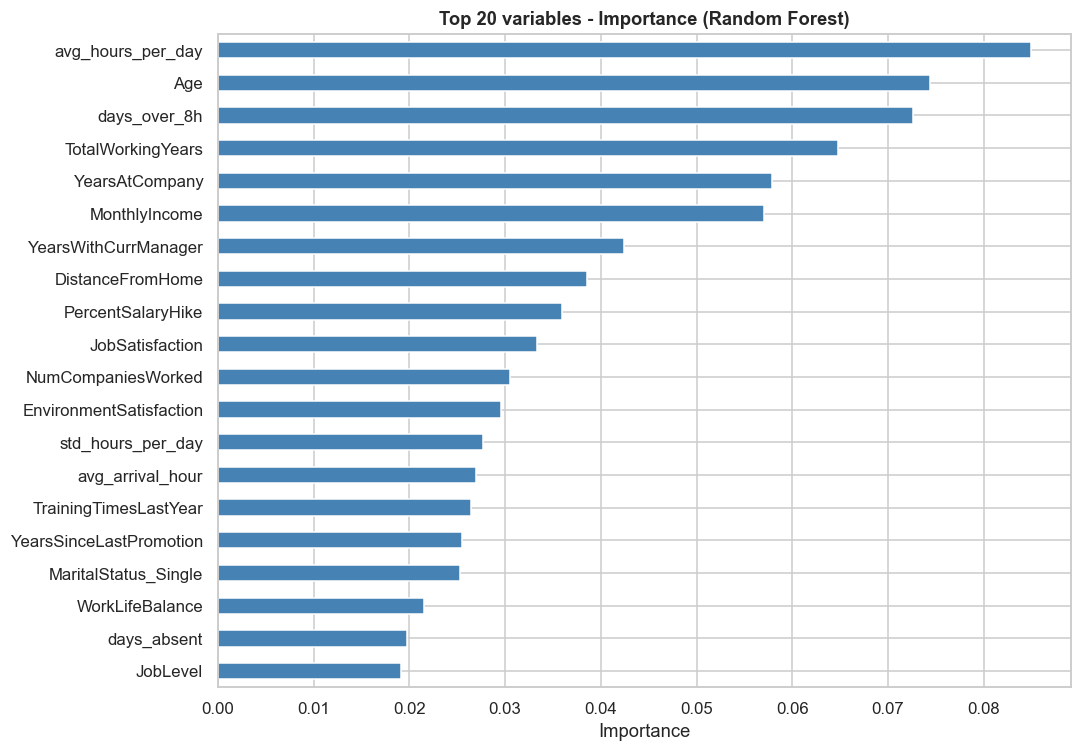

avg_hours_per_day       0.0849
Age                     0.0743
days_over_8h            0.0726
TotalWorkingYears       0.0648
YearsAtCompany          0.0578
MonthlyIncome           0.0570
YearsWithCurrManager    0.0424
DistanceFromHome        0.0386
PercentSalaryHike       0.0360
JobSatisfaction         0.0334


In [16]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
importances.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 20 variables - Importance (Random Forest)", fontweight="bold")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("../outputs/feature_importance_rf.png", bbox_inches="tight")
plt.show()

print(importances.head(10).round(4).to_string())

## Ce qu'on retient

Parmi les 4 familles comparees, le SVM ressort le mieux. La regression logistique est utile comme reference mais plafonne sur la classe minoritaire. L'arbre de decision est le plus interpretable mais moins precis.

Le passage DT vers RF est net : le vote de 100 arbres corrige l'instabilite d'un arbre seul. C'est attendu, c'est exactement pour ca que le RF a ete invente.

Conclusion : le RF est le meilleur modele. On l'optimise dans le notebook 04.